In [6]:

import os
import numpy as np
import nibabel as nib
from scipy.interpolate import interpn
from tqdm.notebook import tqdm
import pandas as pd
import pydicom

In [3]:
def apply_affine(tx,
                 ty,
                 tz,
                 rx,
                 ry,
                 rz,
                 image3d,
                 resolution=(1, 1, 1),
                 method='linear',
                 fill_value=0):

    # Define the affine transformation matrix

    # Create the rotation matrix
    rotx = np.array([[1, 0, 0], [0, np.cos(rx), -np.sin(rx)],
                     [0, np.sin(rx), np.cos(rx)]])

    roty = np.array([[np.cos(ry), 0, np.sin(ry)], [0, 1, 0],
                     [-np.sin(ry), 0, np.cos(ry)]])

    rotz = np.array([[np.cos(rz), -np.sin(rz), 0], [np.sin(rz),
                                                    np.cos(rz), 0], [0, 0, 1]])

    rotation_matrix = np.dot(np.dot(rotx, roty), rotz)

    # Create the affine transformation matrix
    affine = np.array([[
        rotation_matrix[0, 0], rotation_matrix[0, 1], rotation_matrix[0, 2], tx
    ], [
        rotation_matrix[1, 0], rotation_matrix[1, 1], rotation_matrix[1, 2], ty
    ], [
        rotation_matrix[2, 0], rotation_matrix[2, 1], rotation_matrix[2, 2], tz
    ], [0, 0, 0, 1]])

    # create grids of the original image
    center = np.array(image3d.shape) / 2.0

    grids = []
    for dim in range(3):
        grid = np.arange(image3d.shape[dim]) - center[dim]
        grid *= resolution[dim]
        grids.append(grid)

    # Create a meshgrid of coordinates
    x, y, z = np.meshgrid(grids[0], grids[1], grids[2], indexing='ij')

    # Create a coordinates array
    coords = np.array(
        [x.flatten(),
         y.flatten(),
         z.flatten(),
         np.ones_like(x.flatten())]).T

    # Apply the affine transformation
    transformed_coords = np.dot(affine, coords.T).T

    # Interpolate the image values
    image3d2 = interpn(grids,
                       image3d,
                       transformed_coords[:, :3],
                       method=method,
                       bounds_error=False,
                       fill_value=fill_value)
    # Reshape the rotated image
    image3d2 = image3d2.reshape(image3d.shape)

    return image3d2


In [19]:
def rotate_nii(rot_x,
               rot_y,
               rot_z,
               nii,
               method='linear',
               fill_value=0):
    angle_x = rot_x * np.pi / 180.0
    angle_y = rot_y * np.pi / 180.0
    angle_z = rot_z * np.pi / 180.0

    resolution = nii.header.get_zooms()
    resolution = (resolution[1], resolution[0], resolution[2])
    image = nii.get_fdata()

    image = apply_affine(0,
                         0,
                         0,
                         angle_x,
                         angle_y,
                         angle_z,
                         image,
                         resolution=resolution,
                         method=method,
                         fill_value=fill_value)

    new_nii = nib.Nifti1Image(image, nii.affine, nii.header)
    
    return new_nii

In [20]:
def dicom_to_nifti(image_path):
    """
    Convert a directory of DICOM files to a NIfTI image.
    
    Args:
        image_path: Path to directory containing DICOM files
        
    Returns:
        nib.Nifti1Image: NIfTI image object
    """
    # Read all DICOM files from the directory
    dicom_files = []
    for file in sorted(os.listdir(image_path)):
        dicom_files.append(os.path.join(image_path, file))

    # Read all DICOM files and get metadata from first file
    dicoms = [pydicom.dcmread(f) for f in dicom_files]
    first_dcm = dicoms[0]

    # Extract pixel spacing and slice thickness
    pixel_spacing = first_dcm.PixelSpacing
    slice_thickness = first_dcm.SliceThickness

    # Sort slices by z-coordinate of ImagePositionPatient
    dicoms.sort(key=lambda x: float(x.ImagePositionPatient[2]))

    # Stack the pixel arrays to create 3D volume
    volume = np.stack([dcm.pixel_array for dcm in dicoms])

    # Create affine matrix for NIfTI
    # The affine matrix maps from voxel indices to mm coordinates
    affine = np.eye(4)
    affine[0,0] = pixel_spacing[0] 
    affine[1,1] = pixel_spacing[1]
    affine[2,2] = slice_thickness
    affine[0:3,3] = -(np.array(volume.shape) / 2) * np.array([pixel_spacing[0], pixel_spacing[1], slice_thickness])

    # Create NIfTI image
    nifti_img = nib.Nifti1Image(volume, affine)
    
    return nifti_img

# Example usage
image_path = '/dataNAS/people/arogya/projects/noise-simulation/data/imbio/images_22620428'
nifti_img = dicom_to_nifti(image_path)


In [23]:

rotated_nifti = rotate_nii(
    rot_x=5,  # rotate 10 degrees around x-axis
    rot_y=0,   # no rotation around y-axis
    rot_z=0,   # no rotation around z-axis
    nii=nifti_img,
    method='linear',
    fill_value=0
)

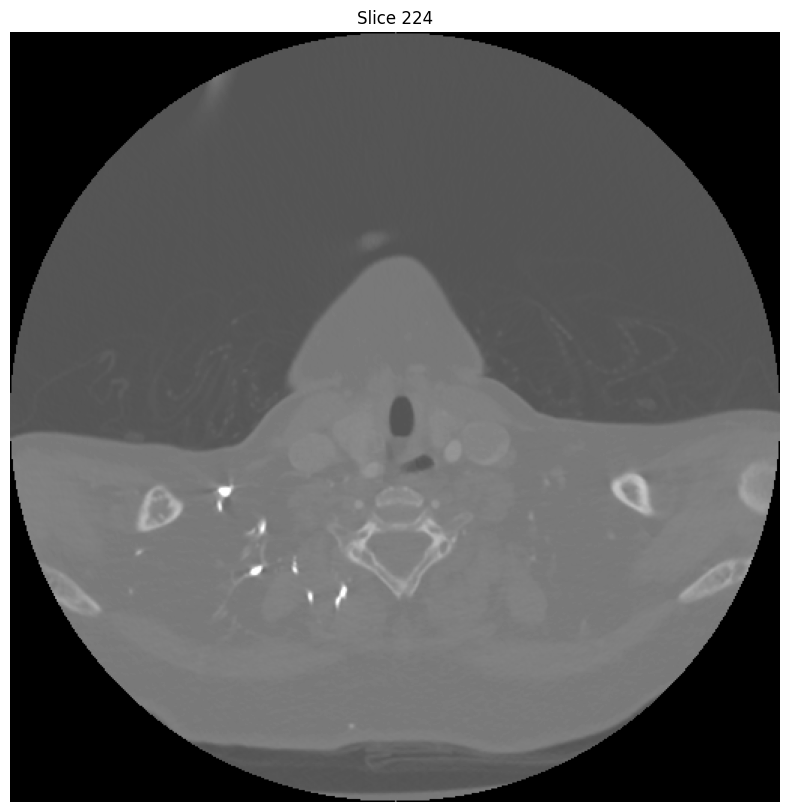

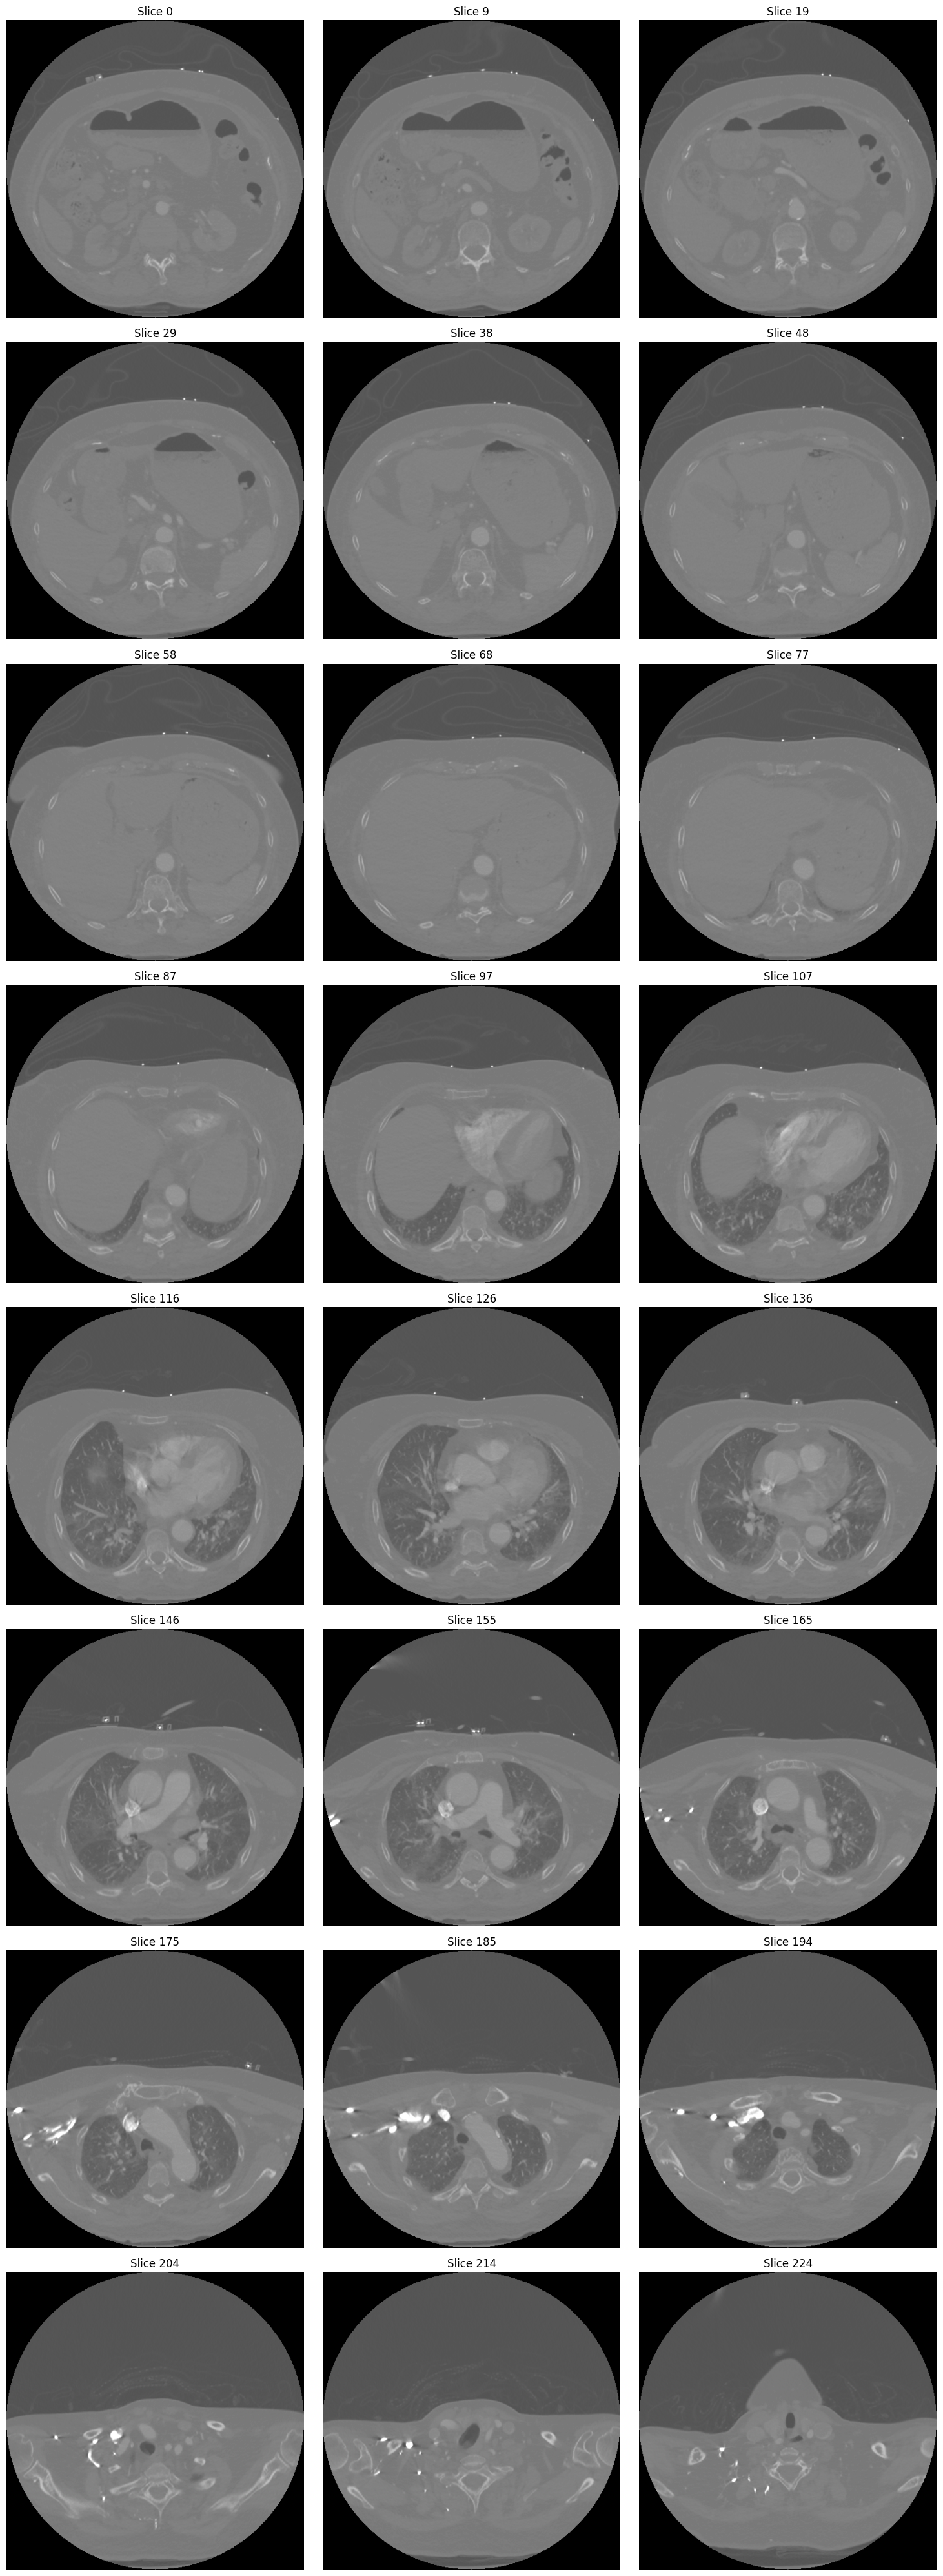

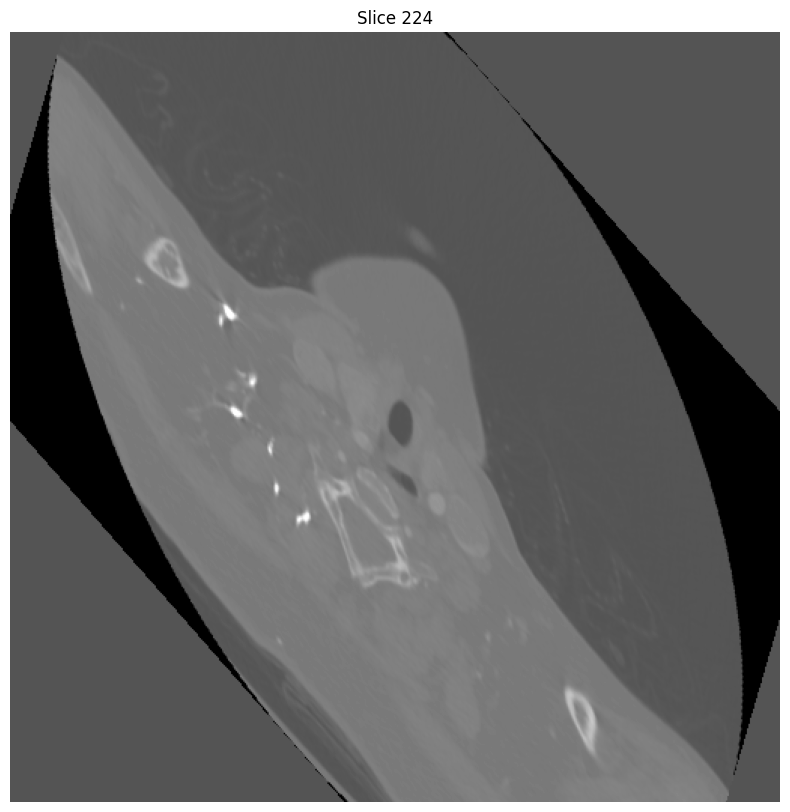

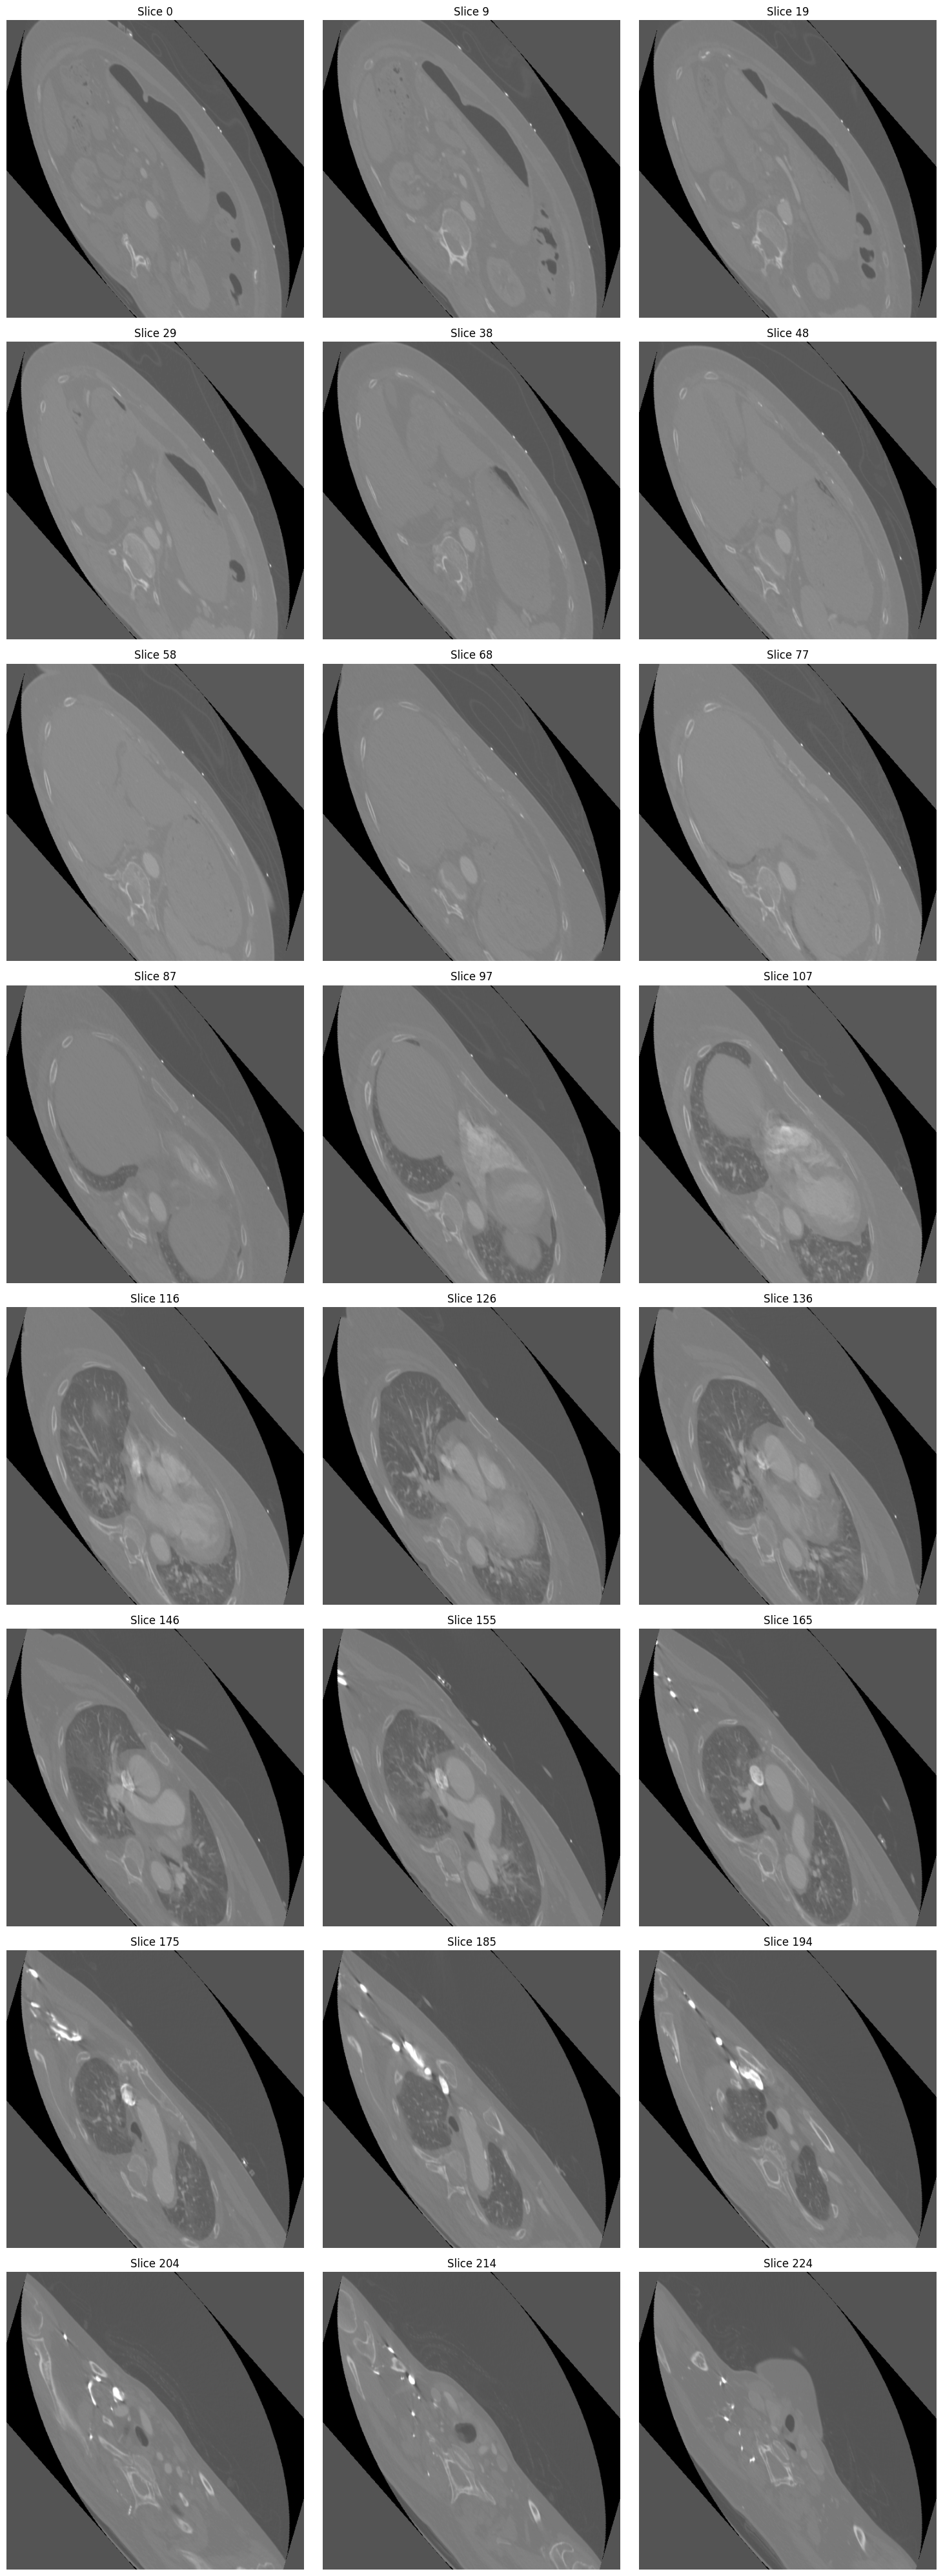

In [22]:
def visualize_nifti(nifti_img, gif_filename='volume_animation.gif'):
    """
    Create an animated GIF and static visualization of NIfTI image slices
    
    Args:
        nifti_img: NIfTI image object
        gif_filename: filename for the output GIF animation
    """
    # Import required libraries
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation, PillowWriter
    
    # Get the 3D volume data from the NIfTI image
    volume_data = nifti_img.get_fdata()

    # Create figure and axes
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)

    # Function to update the frame
    def update(frame):
        ax.clear()
        ax.imshow(volume_data[frame], cmap='gray')
        ax.set_title(f'Slice {frame}')
        ax.axis('off')

    # Create animation
    anim = FuncAnimation(fig, update, frames=volume_data.shape[0],
                        interval=100, repeat=True)

    # Save as GIF
    writer = PillowWriter(fps=20)
    anim.save(gif_filename, writer=writer)

    # Display the saved GIF
    from IPython.display import Image
    Image(filename=gif_filename)

    # Create a figure with multiple slices for static visualization
    n_slices = 24
    fig, axes = plt.subplots(8, 3, figsize=(15, 40))
    slice_indices = np.linspace(0, volume_data.shape[0]-1, n_slices, dtype=int)

    for i, ax in enumerate(axes.flat):
        ax.imshow(volume_data[slice_indices[i]], cmap='gray')
        ax.set_title(f'Slice {slice_indices[i]}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# Example usage
visualize_nifti(nifti_img)  # Visualize original volume
visualize_nifti(rotated_nifti, gif_filename='rotated_volume.gif')  # Visualize rotated volume
